In [267]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [268]:
ORDER = {0: 'First', 1: 'Second', 2: 'Third', 3: 'Total'}

In [269]:
def DataParser(minute, id):
    data = []
    
    for i in range(3):
        data.append(pd.read_csv(f'./Data/{minute}m break/{id:02d}_{i+1}.csv', index_col=0).T.reset_index())
        data[i]['index'] = data[i]['index'].astype(int)
        data[i]['class'] = data[i]['class'].astype(int)
        data[i]['speed'] = data[i]['speed'].astype(float)
    data.append(data[0])
    data[3] = pd.concat([data[3], data[1], data[2]], axis=0, ignore_index=True)
    data[3] = data[3].iloc[:, 1:].reset_index()
    
    return data

In [270]:
def OnePeopleResult(minute, id):
    data = DataParser(minute, id)
    fig, axes = plt.subplots(4, 1, figsize = (12, 18))
    
    for i in range(4):
        ax = axes[i]
    
        # 평균 계산
        mean = np.round(data[i]['speed'].mean(), 4) #소숫점 4자리까지 반올림
        ax.axhline(mean, color = 'gray', linestyle = 'dotted', label = '[ Mean ]')
        ax.text(0, 2.3, f'Maen of Speed = {mean} second per unit', fontsize = 13)
    
        # 모든 데이터 시각화
        ax.plot(data[i]['index'], data[i]['speed'], color = 'blue', label = '[ Correct ]', alpha = 0.3)
    
        # 틀린 데이터 시각화 - 빨강
        w = 3 if i == 3 else 1
        class_data_wrong = data[i][data[i]['class'] == 0]
        ax.text(0, 2.15, f'Number of Wrong Answer = {len(class_data_wrong)}', fontsize = 13)
        ax.bar(class_data_wrong['index'], class_data_wrong['speed'], color = 'red', width = w)
        ax.scatter(class_data_wrong['index'], class_data_wrong['speed'], color = 'red', label = '[ Wrong ]', marker = 'o')
    
        
        ax.set_ylim(0, 2.5)
        if i < 3:
            ax.set_xticks(np.arange(0, 600, 100))
        else:
            ax.set_xticks(np.arange(0, 1800, 100))
    
        ax.set_xlabel('Index')
        ax.set_ylabel('Speed')
        ax.set_title(f'{ORDER[i]} Trial', fontsize = 20)
        ax.legend(title = 'Class', loc = 'upper right')
    
    plt.tight_layout()
    plt.subplots_adjust(hspace = 0.4)
    
    plt.savefig(f'./Graphs/Order by ID/{id:02d}.png', dpi = 200, facecolor = 'lavender')

In [566]:
def GroupResult(minute):
    # [ Preprocessing ]
    
    file_list = os.listdir(f'./Data/{minute}m break')
    id_list = list(set([int(file[:2]) for file in file_list]))
    
    empty_600 = pd.DataFrame({'index': [i for i in range(600)], 'class': [0 for i in range(600)], 'speed': [0 for i in range(600)]})
    empty_1800 = pd.DataFrame({'index': [i for i in range(1800)], 'class': [0 for i in range(1800)], 'speed': [0 for i in range(1800)]})
    empty = [empty_600 for i in range(3)]
    empty.append(empty_1800)
    
    number_of_ids = [pd.Series([0 for i in range(600)], name='numbers') for i in range(3)]
    number_of_ids.append(pd.Series([0 for i in range(1800)], name='numbers'))
    data = [df.copy() for df in empty]
    
    for i in id_list:
        single_result = DataParser(minute, i)
        
        for j in range(4):
            single_result[j] = single_result[j][['index', 'class', 'speed']]
            formatted_result = empty[j][['class','speed']] + single_result[j][['class', 'speed']]

            number_of_ids[j] += formatted_result['class'].notna().astype(int)
            
            data[j][['class', 'speed']] += formatted_result.fillna(0)

    for j in range(4):
        data[j]['class'] = data[j]['class']/(number_of_ids[j].replace(0, 1))
        data[j]['speed'] = data[j]['speed']/(number_of_ids[j].replace(0, 1))
    

    # [ Visualization ]
    
    fig, axes = plt.subplots(4, 1, figsize = (12, 18))
    
    for i in range(4):
        text_x = 30 if i == 3 else 10
        text_y = 1.22

        ax1 = axes[i]
        ax2 = ax1.twinx()
    
        # 평균 계산
        mean = np.round(data[i]['speed'].mean(), 4) #소숫점 4자리까지 반올림
        ax1.plot(mean, color = 'gray', linestyle = 'dotted', label = '[ Mean ]')
    
        # 오답 히스토그램 - 빨강
        w = 3 if i == 3 else 1
        wrong_rate = data[i]['class']
        
        if i < 3:
            wrong_range = range(len(wrong_rate)//10)
            ax1.set_xticks(np.arange(0, 600, 100))
            ax2.bar(np.array(wrong_range)*10, [wrong_rate[j*10:(j+1)*10].mean() for j in wrong_range], color='mediumseagreen', alpha=0.2, label='[ Accuracy ]', width=10, align='edge')
        else:
            wrong_range = range(len(wrong_rate)//30)
            ax1.set_xticks(np.arange(0, 1800, 100))
            ax2.bar(np.array(wrong_range)*30, [wrong_rate[j*30:(j+1)*30].mean() for j in wrong_range], color='mediumseagreen', alpha=0.2, label='[ Accuracy ]', width=30, align='edge')
        
        # 응답 시간 산점도
        ax1.scatter(data[i]['index'], data[i]['speed'], s=10, color = 'royalblue', label = '[ speed ]', alpha = 0.6)
    
        ax1.set_ylim(0.5, 1.2)
        ax2.set_ylim(0.8, 1)
        ax1.set_xlabel('Index')
        ax1.set_ylabel('Response Time')
        ax2.set_ylabel('Accuracy')
        ax1.set_title(f'{ORDER[i]} Trial', fontsize = 20)
        ax1.legend(title = 'Class', loc = 'upper right')
        
        # 추세선
        fit_line = np.polyfit(data[i]['index'][10:]-1, data[i]['speed'][10:], 1)
        x_minmax = np.array([10, len(data[i]['index']-1)])
        fit_y = x_minmax * fit_line[0] + fit_line[1]
        ax1.plot(x_minmax, fit_y, color='red', linewidth = 3)
        ax1.text(text_x, text_y - 0.17, f'Mean of Response Time = {mean} second per unit\nMean of Accuracy = {np.round(wrong_rate.mean(), 4)}\nslope = %.6f'%(fit_line[0]), fontsize=13, bbox=dict(boxstyle='round', facecolor='white', edgecolor='grey', alpha=0.7))
        ax1.margins(x=0)
        
    plt.tight_layout()
    plt.subplots_adjust(hspace = 0.4)
    
    plt.savefig(f'./Graphs/Order by Group/{minute}m break.png', dpi = 200, facecolor = 'lightblue')
    plt.show()

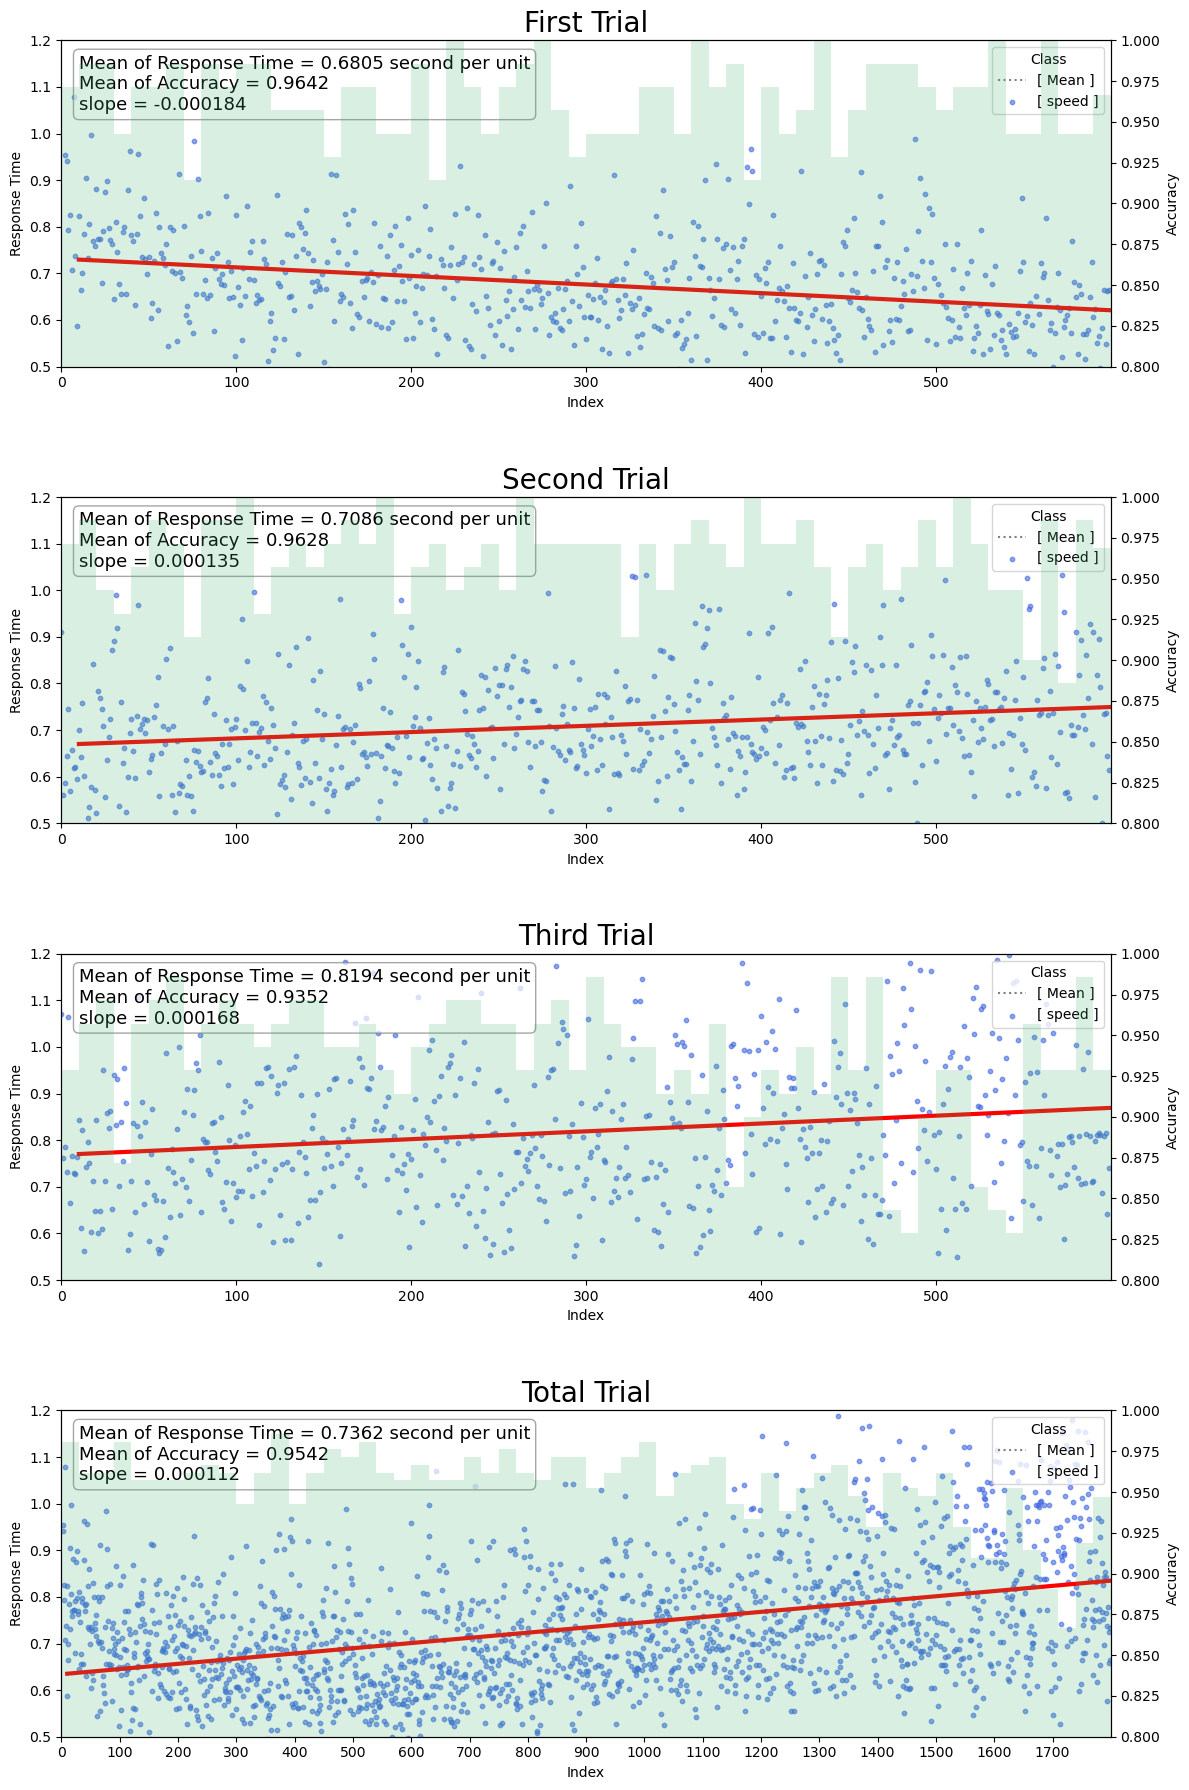

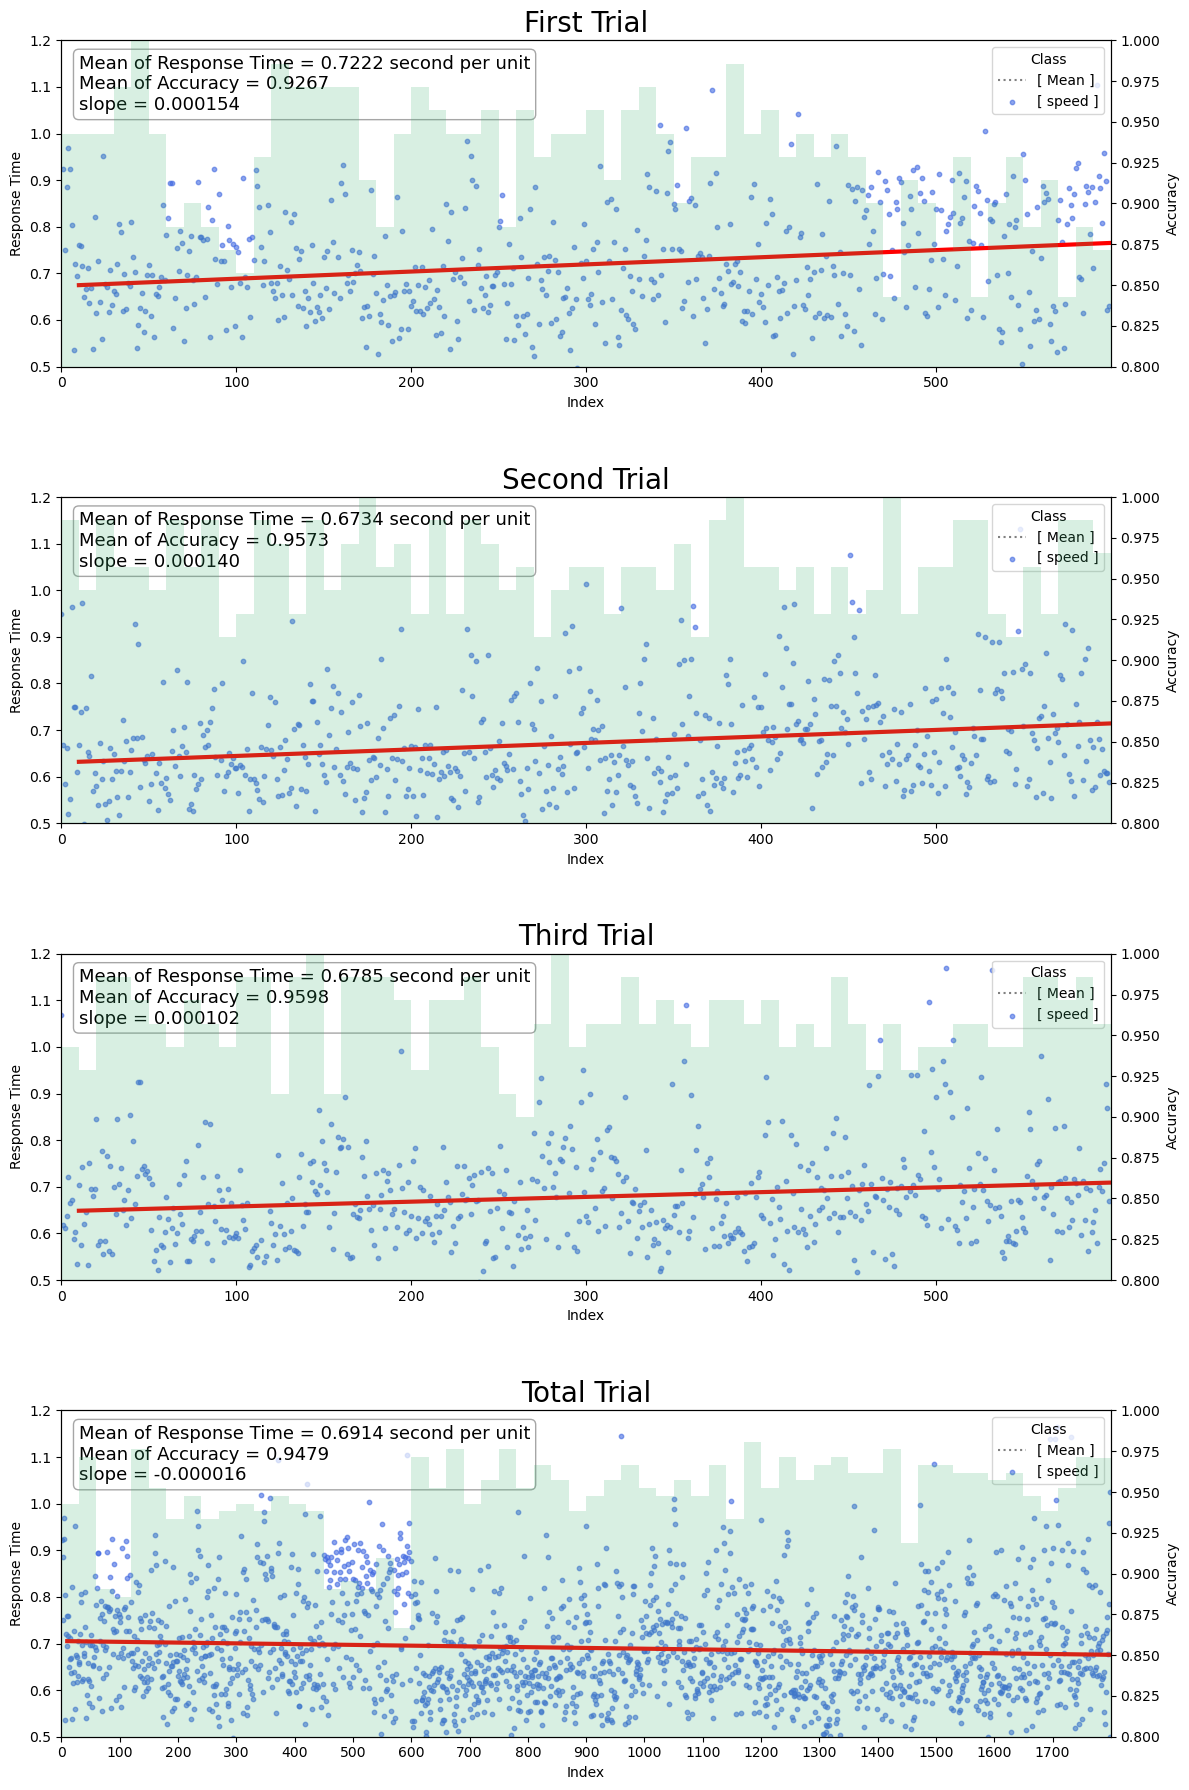

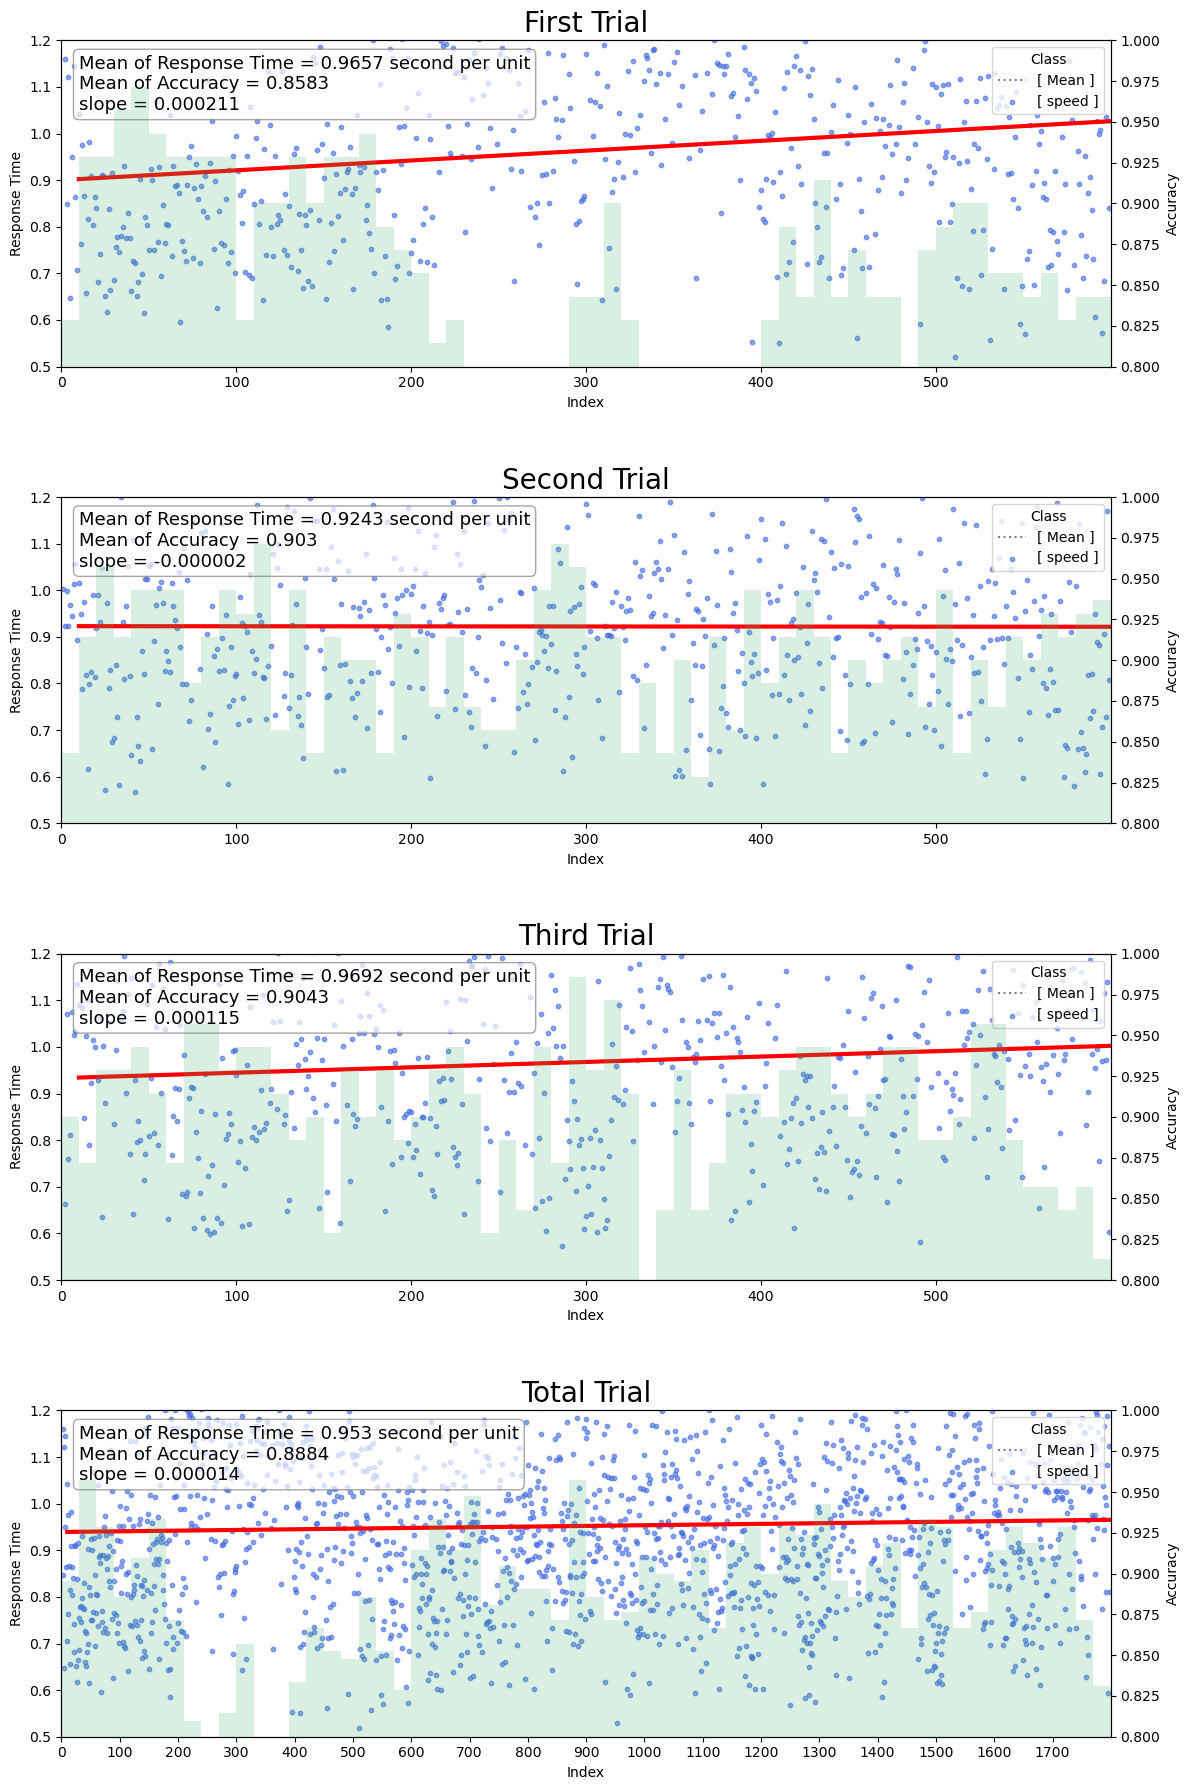

In [567]:

GroupResult(0)
GroupResult(5)
GroupResult(10)
